# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Diana Qisthin Thoniyah
- **Email:** cdcc299d6x2345@devacademy.id
- **ID Dicoding:** dianathoniyah

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Faktor apa saja yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian sepanjang tahun 2011?
- **Pertanyaan 2:** Jam berapa penyewaan sepeda mengalami peningkatan baik pada hari kerja maupun libur berdasarkan data per jam tahun 2011-2012?
- **Pertanyaan 3:** Bagaimana perbandingan rerata penyewaan harian antara pengguna casual dengan registered pada setiap musim tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Day

In [313]:
file_id = '1lB8FgL2ahWzxveqjrBdBuetmJR-C3A15'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
day_df = pd.read_csv(url)
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset day_df terdiri dari 16 kolom, mulai dari instant sebagai nomor urut hingga cnt sebagai total dari penyewaan casual dan registered
- Dataset day_df menampilkan data penyewaan harian, dilengkapi dengan kolom suhu, musim, dan cuaca
- Data dimulai dari tanggal 1 Januari 2011

#### Load df Hour

In [314]:
file_id = '1dLPMV7fwcrDen9zNKKXgIiSTZLsPQmm_'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
hour_df = pd.read_csv(url)
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Insight: (Opsional)

- Dataset hour_df terdiri dari 17 kolom, kolom hr (hour) sebagai tambahan dataset penyewaan hour
- Menampilkan data penyewaan per jam dilengkapi dengan informasi musim, cuaca, dan suhu

### Assessing Data

Menilai tabel day_df

In [315]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [316]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [317]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [318]:
day_df.duplicated().sum()

np.int64(0)

In [319]:
for col in ['casual', 'registered', 'cnt']:
    data = day_df[col]

    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off

    outliers = [x for x in data if x < minimum or x > maximum]

    print(f"{col}: {len(outliers)} outliers")

casual: 44 outliers
registered: 0 outliers
cnt: 0 outliers


Menilai tabel hour_df

In [320]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [321]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [322]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [323]:
hour_df.duplicated().sum()

np.int64(0)

In [324]:
for col in ['casual', 'registered', 'cnt']:
    data = hour_df[col]

    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off

    outliers = [x for x in data if x < minimum or x > maximum]

    print(f"{col}: {len(outliers)} outliers")

casual: 1192 outliers
registered: 680 outliers
cnt: 505 outliers


#### Identifying incorrect datatype problem

In [325]:
print(day_df['dteday'].dtype)
print(hour_df['dteday'].dtype)

object
object


#### Identifying column naming problem

In [326]:
print("Kolom pada dataset day_df:")
day_df.columns

Kolom pada dataset day_df:


Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

#### Identifying unmapped categorical value problem

In [327]:
print("Nilai season:", day_df['season'].unique())
print("Nilai weathersit:", day_df['weathersit'].unique())

Nilai season: [1 2 3 4]
Nilai weathersit: [2 1 3]


**Steps to Take:**
- Mengubah tipe data kolom dteday pada day_df dari object menjadi datetime
- Mengubah tipe data kolom dteday pada hour_df dari object menjadi datetime
- Membiarkan outlier yang ada pada kolom cnt dataset hour_df karena merupakan data yang berisikan jumlah penyewaan casual dan registered dalam sehari
- Mapping nilai kategorikal pada kolom season dan weathersit
- Mengubah nama kolom agar lebih mudah dipahami
- Menghapus kolom instant

**Insight:** (Opsional)
- Kesalahan tipe data pada kolom dteday pada kedua dataset
- Terdapat 505 outlier pada kolom cnt di hour_df
- Tidak ada masalah duplikasi atau missing value pada kedua dataset
- Nama kolom pada kedua dataset perlu diperbaiki agar lebih mudah dipahami (contoh: dteday menjadi date, cnt menjadi total_rental, hum menjadi humidity, dan lain-lain)
- Kolom instant pada kedua dataset akan dihapus karena tidak merepresentasikan identitas penyewa (tidak diperlukan)
- Meskipun pada file README sumber data menyampaikan dengan jelas makna angka yang digunakan pada kolom-kolom kategorikal (contoh: season dan weathersit), tetap harus di-mapping agar memudahkan dalam menganalisis data

### Cleaning Data

#### Fixing incorrect datatype problem

In [328]:
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])
    hour_df[column] = pd.to_datetime(hour_df[column])

print(day_df['dteday'].dtype)
print(hour_df['dteday'].dtype)

datetime64[ns]
datetime64[ns]


#### Fixing column naming problem

In [329]:
# day_df
day_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'hum': 'humidity',
    'windspeed': 'wind_speed',
    'cnt': 'total_rentals'
}, inplace=True)

# hour_df
hour_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather',
    'hum': 'humidity',
    'windspeed': 'wind_speed',
    'cnt': 'total_rentals'
}, inplace=True)

day_df.columns, hour_df.columns

(Index(['instant', 'date', 'season', 'year', 'month', 'holiday', 'weekday',
        'workingday', 'weather', 'temp', 'atemp', 'humidity', 'wind_speed',
        'casual', 'registered', 'total_rentals'],
       dtype='object'),
 Index(['instant', 'date', 'season', 'year', 'month', 'hour', 'holiday',
        'weekday', 'workingday', 'weather', 'temp', 'atemp', 'humidity',
        'wind_speed', 'casual', 'registered', 'total_rentals'],
       dtype='object'))

#### Fixing unused column problem

In [330]:
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)

day_df.columns, hour_df.columns

(Index(['date', 'season', 'year', 'month', 'holiday', 'weekday', 'workingday',
        'weather', 'temp', 'atemp', 'humidity', 'wind_speed', 'casual',
        'registered', 'total_rentals'],
       dtype='object'),
 Index(['date', 'season', 'year', 'month', 'hour', 'holiday', 'weekday',
        'workingday', 'weather', 'temp', 'atemp', 'humidity', 'wind_speed',
        'casual', 'registered', 'total_rentals'],
       dtype='object'))

#### Fixing unmapped categorical values problem

In [331]:
# Mengubah nilai kolom season menjadi kategori
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mengubah nilai kolom weather menjadi kategori
day_df['weather'] = day_df['weather'].map({1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow'})
hour_df['weather'] = hour_df['weather'].map({1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow'})

# Mengubah tipe data kolom season menjadi kategori
day_df['season'] = day_df['season'].astype('category')
hour_df['season'] = hour_df['season'].astype('category')

# Mengubah tipe data kolom weather menjadi kategori
day_df['weather'] = day_df['weather'].astype('category')
hour_df['weather'] = hour_df['weather'].astype('category')

# Melihat hasil nilai yang diubah
print("Nilai season:", day_df['season'].unique())
print("Nilai weather:", day_df['weather'].unique())

# Melihat hasil tipe data yang diubah
print(day_df['season'].dtype)
print(hour_df['season'].dtype)

Nilai season: ['Spring', 'Summer', 'Fall', 'Winter']
Categories (4, object): ['Fall', 'Spring', 'Summer', 'Winter']
Nilai weather: ['Mist/Cloudy', 'Clear', 'Light Rain/Snow']
Categories (3, object): ['Clear', 'Light Rain/Snow', 'Mist/Cloudy']
category
category


**Insight:** (Opsional)
- Tipe data kolom dteday pada kedua dataset sudah diperbaiki dan menunjukkan tipe data yang seharusnya, yaitu datetime
- Beberapa nama kolom pada kedua dataset sudah diubah dan dapat dipahami dengan jelas
- Kolom kategorikal (weather dan season) sudah di-mapping dan tipe datanya diganti menjadi **category** sehingga nilai kuartil, mean, median, dan lainnya terkait dengan numerik tidak akan bisa dilihat
- Kolom instant sudah dihapus

## Exploratory Data Analysis (EDA)

### Explore day_df

In [332]:
day_df.sample(5)

,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
9,2011-01-10,Spring,0,1,0,1,1,Clear,0.150833,0.150888,0.482917,0.223267,41,1280,1321
450,2012-03-26,Summer,1,3,0,1,1,Clear,0.445833,0.438750,0.477917,0.386821,795,4763,5558
222,2011-08-11,Fall,0,8,0,4,1,Clear,0.717500,0.651521,0.423750,0.164796,812,3980,4792
338,2011-12-05,Winter,0,12,0,1,1,Mist/Cloudy,0.385833,0.393925,0.827083,0.062208,233,3578,3811
684,2012-11-15,Winter,1,11,0,4,1,Mist/Cloudy,0.321667,0.324492,0.620417,0.152987,320,5125,5445


In [333]:
day_df.describe(include="all")

,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
count,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,NaN,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,0.500684,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,0.000000,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,1.000000,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,1.000000,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,1.000000,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


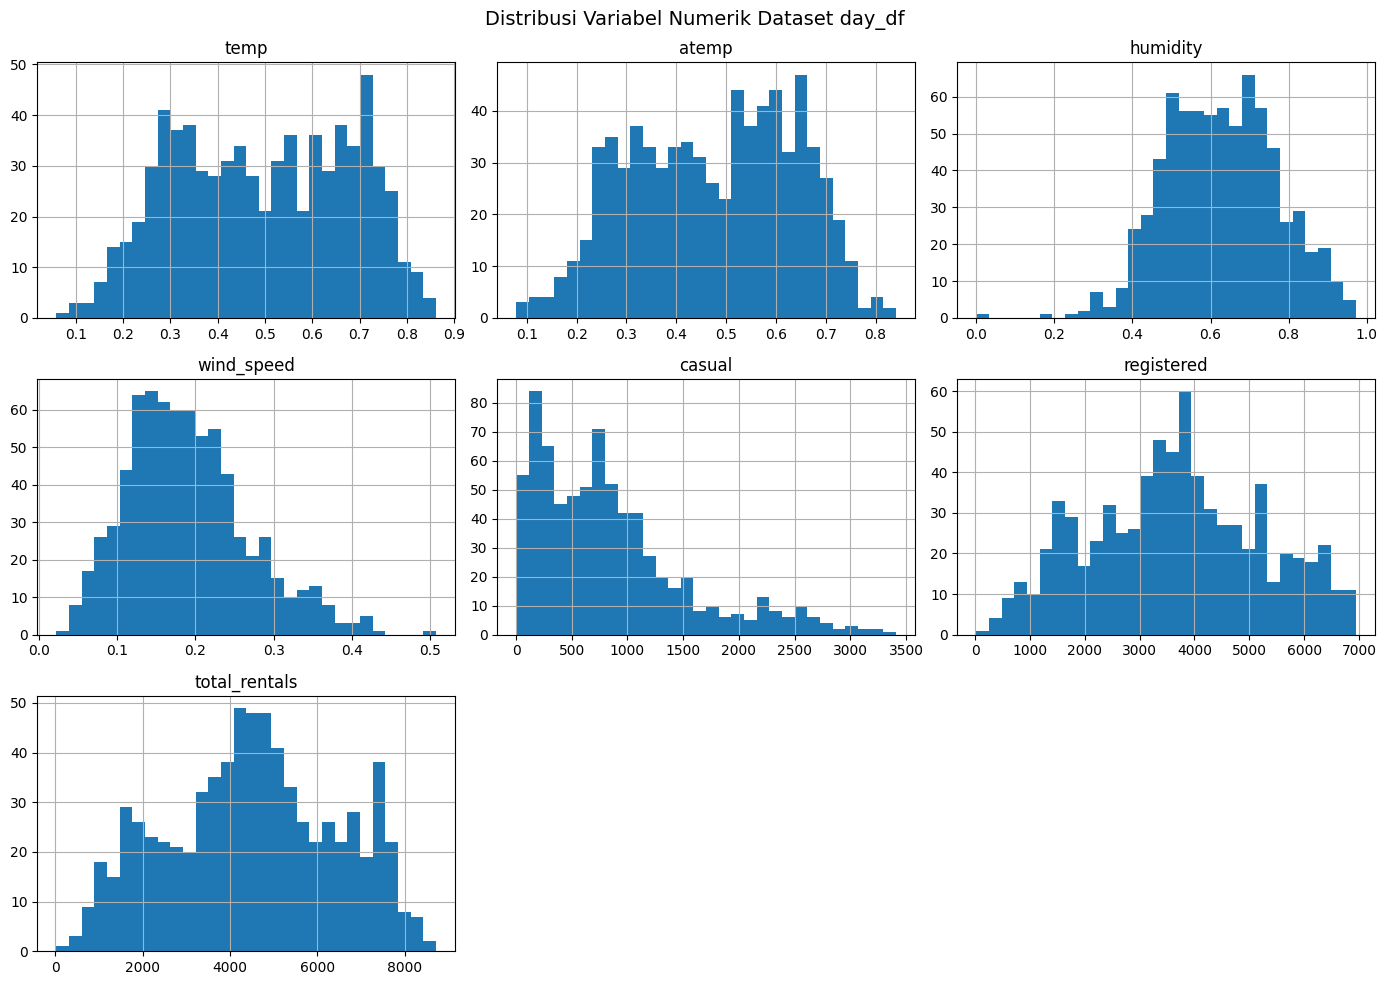

In [350]:
cols = ['temp', 'atemp', 'humidity', 'wind_speed',
        'casual', 'registered', 'total_rentals']

day_df[cols].hist(figsize=(14, 10), bins=30)
plt.suptitle('Distribusi Variabel Numerik Dataset day_df', fontsize=14)

plt.tight_layout()

**Insight:** (Opsional)

Dataset day_df
- Berdasarkan hasil describe (), tidak ada data anomali
- Distribusi casual condong ke kanan (right-skewed), artinya penyewa casual cenderung tidak rutin menyewa sepeda
- Distribusi total_rentals memiliki dua puncak, **kemungkinan** karena adanya perbedaan volume penyewaan antara tahun 2011 dan 2012 yang cukup signifikan
- Distribusi temp dan atemp cukup merata, menandakan dataset mencakup berbagai kondisi suhu dari semua musim dengan baik

### Explore hour_df

In [335]:
hour_df.sample(5)

,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
6806,2011-10-16,Winter,0,10,4,0,0,0,Clear,0.42,0.4242,0.54,0.1940,5,7,12
3493,2011-05-30,Summer,0,5,11,1,1,0,Clear,0.82,0.7727,0.52,0.0000,153,168,321
14601,2012-09-05,Fall,1,9,14,0,3,1,Clear,0.82,0.7879,0.56,0.1045,34,177,211
10102,2012-03-02,Spring,1,3,0,0,5,1,Clear,0.34,0.3333,0.53,0.1642,1,45,46
12557,2012-06-12,Summer,1,6,10,0,2,1,Light Rain/Snow,0.64,0.5758,0.89,0.2836,29,96,125


In [336]:
hour_df.describe(include="all")

,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals
count,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17376,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-02 04:08:34.552045568,NaN,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,NaN,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,NaN,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,NaN,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,NaN,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


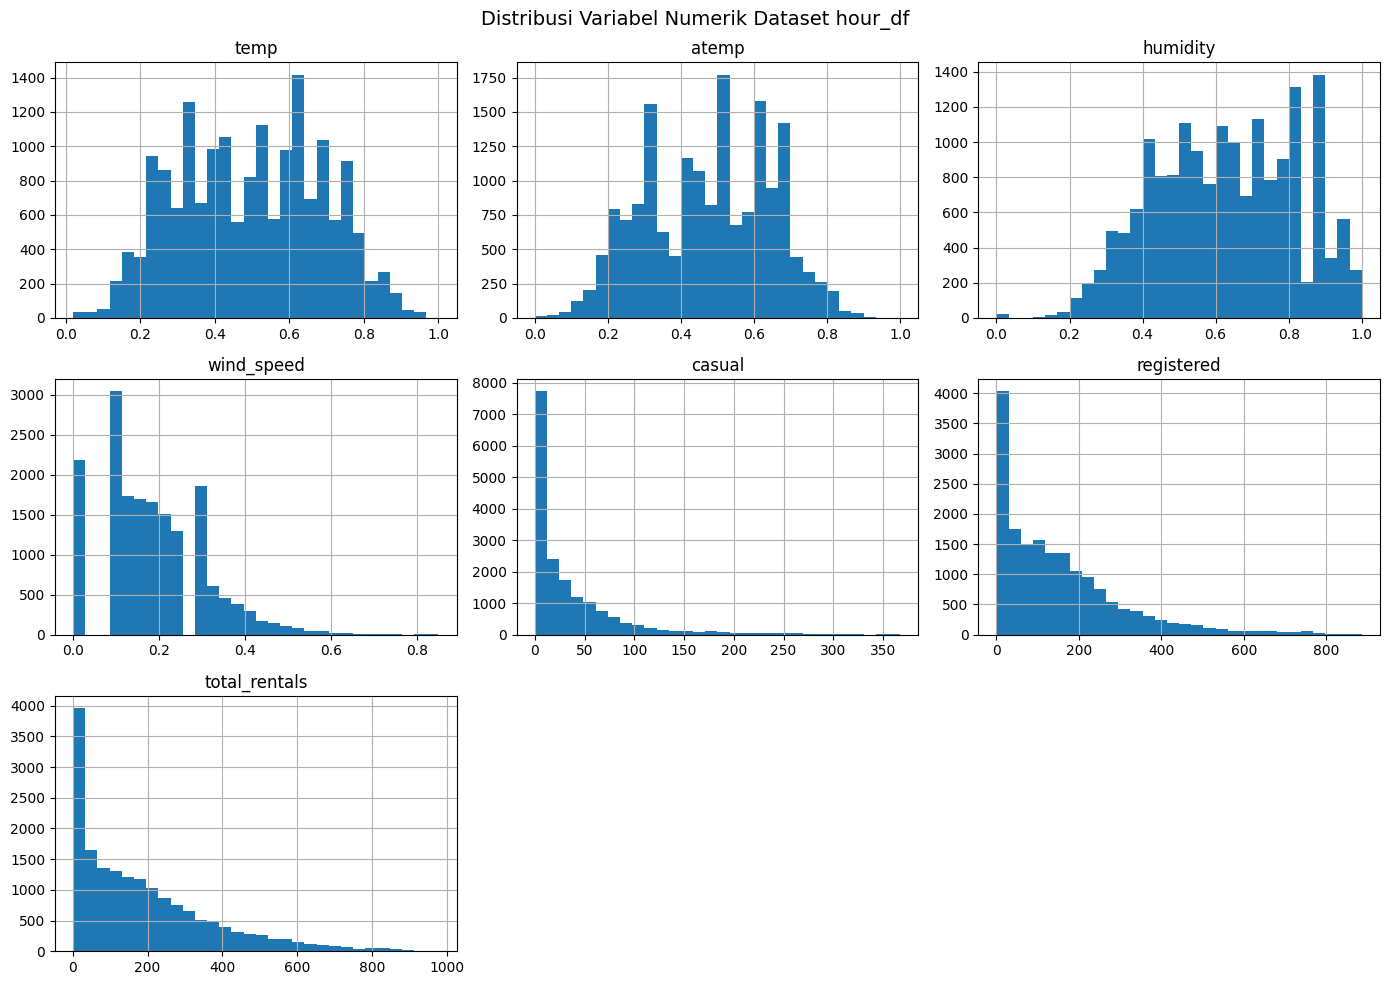

In [351]:
cols = ['temp', 'atemp', 'humidity', 'wind_speed',
        'casual', 'registered', 'total_rentals']

hour_df[cols].hist(figsize=(14, 10), bins=30)
plt.suptitle('Distribusi Variabel Numerik Dataset hour_df', fontsize=14)
plt.tight_layout()

**Insight:** (Opsional)

Dataset hour_df
- Berdasarkan hasil describe, tidak ada data anomali pada dataset hour_df
- Distribusi casual, registered, dan total_rentals skewness positif karena saat malam hingga dini hari (misalnya pukul 00.00–05.00) hampir tidak ada aktivitas penyewaan, sehingga banyak nilai yang mendekati nol
- Distribusi wind_speed condong ke kanan, menunjukkan bahwa kondisi angin kencang jarang terjadi dan sebagian besar waktu kecepatan angin tergolong rendah hingga sedang
- Distribusi humidity cenderung condong ke kiri, artinya sebagian besar waktu kondisi kelembapan udara cukup tinggi

### Explore Pertanyaan 1

In [337]:
day_2011 = day_df[day_df['year'] == 0]
rerata_harian = day_2011['total_rentals'].mean()
print(f"Rerata harian 2011: {rerata_harian:.2f}")

Rerata harian 2011: 3405.76


In [338]:
print(day_2011.groupby('season')['total_rentals'].mean())

season
Fall      4464.361702
Spring    1666.666667
Summer    3775.173913
Winter    3664.460674
Name: total_rentals, dtype: float64


/tmp/ipykernel_4771/3328213616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_2011.groupby('season')['total_rentals'].mean())


In [339]:
print(day_2011.groupby('weather')['total_rentals'].mean())

weather
Clear              3694.986726
Light Rain/Snow    1674.133333
Mist/Cloudy        3088.096774
Name: total_rentals, dtype: float64


/tmp/ipykernel_4771/3680232138.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_2011.groupby('weather')['total_rentals'].mean())


In [340]:
print(day_2011.groupby('workingday')['total_rentals'].mean())

workingday
0    3363.817391
1    3425.056000
Name: total_rentals, dtype: float64


### Explore Pertanyaan 2

In [341]:
print("Rerata penyewaan per jam (hari kerja vs libur):")
print(hour_df.groupby(['hour', 'workingday'])['total_rentals'].mean())

Rerata penyewaan per jam (hari kerja vs libur):
hour  workingday
0     0              90.800000
      1              36.786290
1     0              69.508696
      1              16.552632
2     0              53.171053
      1               8.683778
3     0              25.775330
      1               4.942553
4     0               8.264317
      1               5.429787
5     0               8.689189
      1              24.913131
6     0              18.742358
      1             102.500000
7     0              43.406926
      1             290.612903
8     0             105.653680
      1             477.006048
9     0             171.623377
      1             241.518145
10    0             255.909091
      1             135.366935
11    0             315.316017
      1             158.229839
12    0             366.259740
      1             200.820926
13    0             372.731602
      1             198.429719
14    0             364.645022
      1             183.572289
15   

### Explore Pertanyaan 3

In [342]:
day_2012 = day_df[day_df['year'] == 1]
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

print("Rerata casual vs registered per musim 2012:")
print(day_2012.groupby('season', observed=True)[['casual', 'registered']].mean().reindex(season_order))

Rerata casual vs registered per musim 2012:
             casual   registered
season                          
Spring   430.736264  3100.560440
Summer  1369.108696  4840.380435
Fall    1389.797872  5434.446809
Winter   864.820225  4927.044944


**Insight:** (Opsional)
- Berdasarkan hasil describe(), data day_df dan hour_df tidak memiliki anomali pada nilai-nilainya
- Rerata harian penyewaan sepeda pada tahun 2011 adalah 3405.76, dengan musim Fall rerata tertinggi dan musim Spring terendah
- Cuaca cerah (Clear) memiliki rerata penyewaan tertinggi, sementara cuaca hujan/salju paling rendah
- Perbedaan rerata penyewaan antara hari kerja dan hari libur tidak signifikan
- Pada hari kerja, penyewaan memuncak di jam 8 pagi dan 17-18 sore
- Pada hari libur, penyewaan tertinggi di rentang jam 11-15 siang
- Pengguna registered mendominasi penyewaan di semua musim dibandingkan casual, keduanya mencapai puncak di musim Fall
-  

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor apa saja yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian sepanjang tahun 2011?

/tmp/ipykernel_4771/518107810.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_avg = day_2011.groupby('season')['total_rentals'].mean()
/tmp/ipykernel_4771/518107810.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_avg = day_2011.groupby('weather')['total_rentals'].mean()


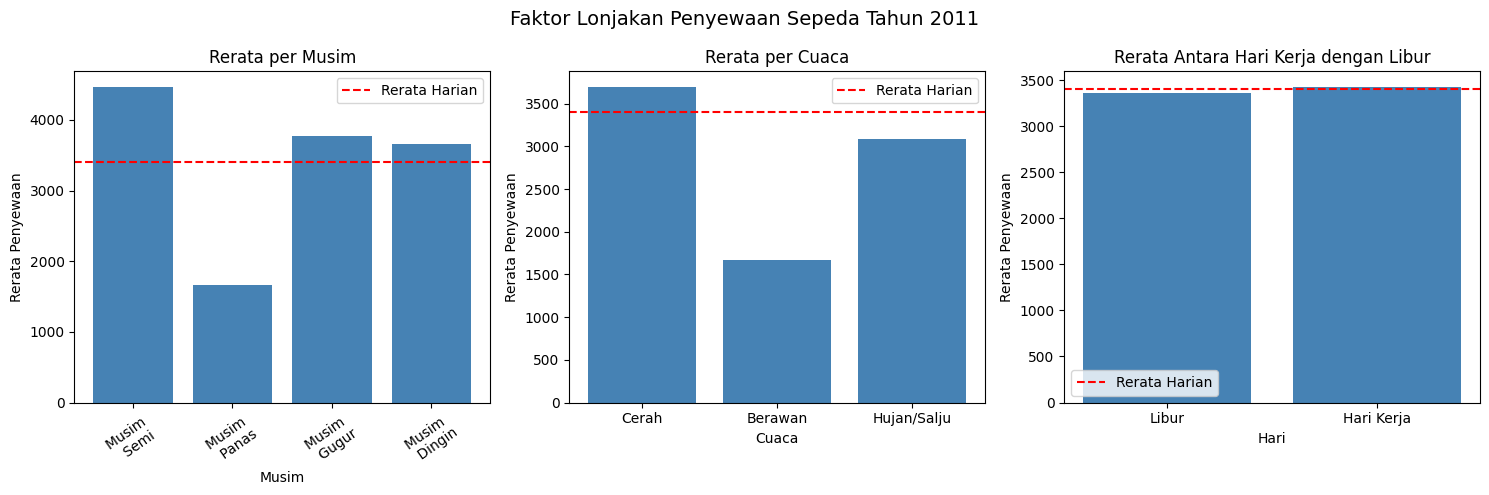

In [361]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Faktor Lonjakan Penyewaan Sepeda Tahun 2011', fontsize=14)

# Rerata per musim
season_avg = day_2011.groupby('season')['total_rentals'].mean()

axes[0].bar(
    ['Musim \n Semi','Musim \n Panas','Musim \n Gugur','Musim \n Dingin'],
    season_avg,
    color='steelblue'
)

axes[0].tick_params(axis='x', rotation=35)

axes[0].axhline(
    y=rerata_harian,
    color='red',
    linestyle='--',
    label='Rerata Harian'
)

axes[0].set_title('Rerata per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rerata Penyewaan')
axes[0].legend()

# Rerata per cuaca
weather_avg = day_2011.groupby('weather')['total_rentals'].mean()

axes[1].bar(
    ['Cerah','Berawan','Hujan/Salju'],
    weather_avg,
    color='steelblue'
)

axes[1].axhline(
    y=rerata_harian,
    color='red',
    linestyle='--',
    label='Rerata Harian'
)

axes[1].set_title('Rerata per Cuaca')
axes[1].set_xlabel('Cuaca')
axes[1].set_ylabel('Rerata Penyewaan')
axes[1].legend()


# Rerata hari kerja vs libur
workingday_avg = day_2011.groupby('workingday')['total_rentals'].mean()

axes[2].bar(
    ['Libur','Hari Kerja'],
    workingday_avg,
    color='steelblue'
)

axes[2].axhline(
    y=rerata_harian,
    color='red',
    linestyle='--',
    label='Rerata Harian'
)

axes[2].set_title('Rerata Antara Hari Kerja dengan Libur')
axes[2].set_xlabel('Hari')
axes[2].set_ylabel('Rerata Penyewaan')
axes[2].legend()


plt.tight_layout()

### Pertanyaan 2: Jam berapa penyewaan sepeda mengalami peningkatan baik pada hari kerja maupun libur berdasarkan data per jam tahun 2011-2012?

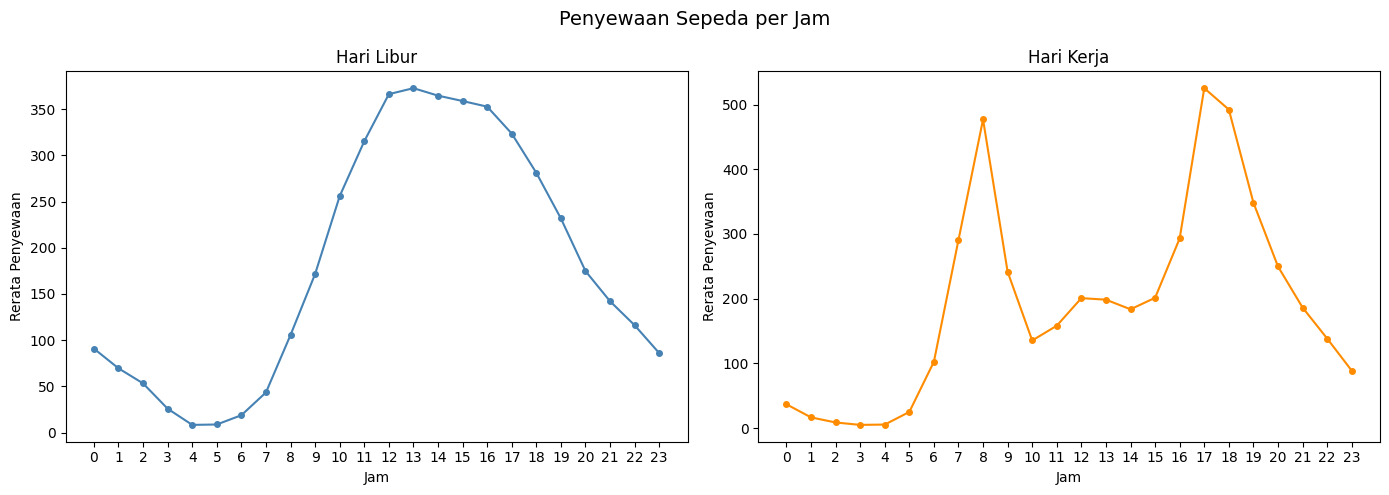

In [353]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Penyewaan Sepeda per Jam', fontsize=14)

workingday_labels = {0: 'Hari Libur', 1: 'Hari Kerja'}
colors = {0: 'steelblue', 1: 'darkorange'}

for wd in [0, 1]:
    data = hour_df[hour_df['workingday'] == wd].groupby('hour')['total_rentals'].mean()
    axes[wd].plot(data.index, data.values, color=colors[wd], marker='o', markersize=4)
    axes[wd].set_title(workingday_labels[wd])
    axes[wd].set_xlabel('Jam')
    axes[wd].set_ylabel('Rerata Penyewaan')
    axes[wd].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana perbandingan rerata penyewaan harian antara pengguna casual dengan registered pada setiap musim tahun 2012?

/tmp/ipykernel_4771/2551634535.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_2012_season = day_2012.groupby('season')[['casual', 'registered']].mean()


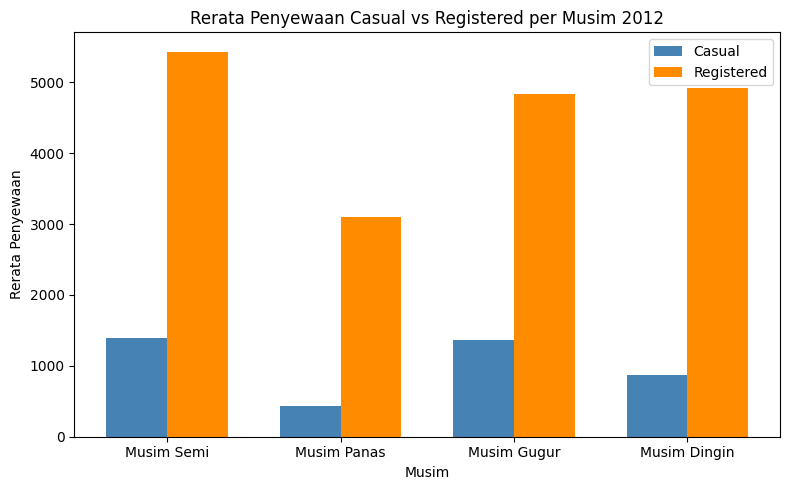

In [355]:
fig, ax = plt.subplots(figsize=(8, 5))

season_labels = ['Musim Semi', 'Musim Panas', 'Musim Gugur', 'Musim Dingin']
day_2012_season = day_2012.groupby('season')[['casual', 'registered']].mean()

x = np.arange(len(season_labels))
width = 0.35

ax.bar(x - width/2, day_2012_season['casual'], width, label='Casual', color='steelblue')
ax.bar(x + width/2, day_2012_season['registered'], width, label='Registered', color='darkorange')

ax.set_title('Rerata Penyewaan Casual vs Registered per Musim 2012')
ax.set_xlabel('Musim')
ax.set_ylabel('Rerata Penyewaan')
ax.set_xticks(x)
ax.set_xticklabels(season_labels)
ax.legend()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Musim Fall memiliki rerata penyewaan tertinggi dan jauh melampaui rerata harian, sementara musim Spring paling rendah
- Cuaca cerah berhubungan positif dengan lonjakan penyewaan, sedangkan cuaca hujan/salju paling rendah
- Perbedaan banyaknya penyewa antara hari kerja dengan libur tidak signifikan
- Hari kerja menunjukkan pola bimodal dengan puncak jam 8 pagi dan 17 sore
- Hari libur menunjukkan pola satu puncak di jam 12-13 siang
- Pengguna registered mendominasi penyewaan di semua musim dibandingkan casual
- Pengguna registered lebih konsisten di semua musim, sedangkan casual lebih fluktuatif dan sangat dipengaruhi musim

## Analisis Lanjutan (Opsional)

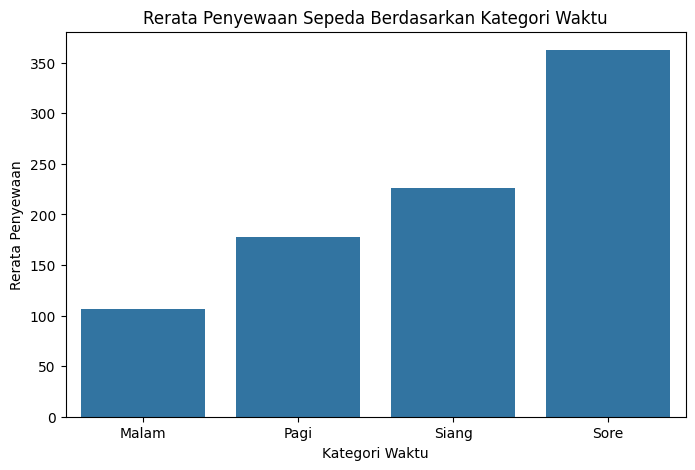

In [371]:
# Kategori waktu berdasarkan waktu
def categorize_time(hour):
    if 5 <= hour < 10:
        return "Pagi"
    elif 10 <= hour < 15:
        return "Siang"
    elif 15 <= hour < 19:
        return "Sore"
    else:
        return "Malam"

hour_df["time_category"] = hour_df["hour"].apply(categorize_time)

time_grouped = hour_df.groupby("time_category")["total_rentals"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x="time_category",
    y="total_rentals",
    data=time_grouped
)

plt.title("Rerata Penyewaan Sepeda Berdasarkan Kategori Waktu")
plt.xlabel("Kategori Waktu")
plt.ylabel("Rerata Penyewaan")

plt.show()

**Insight:**

Penyewaan banyak dilakukan saat sore hari berdasarkan dataset hour_df

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Faktor yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian tahun 2011 adalah musim Fall (gugur), cuaca cerah, dan hari kerja. Musim Fall mencatat rerata tertinggi (~4464) jauh melampaui rerata harian (3405.76), cuaca cerah mendorong penyewaan di atas rerata, sementara perbedaan antara hari kerja dengan libur tidak signifikan
- **Conclusion pertanyaan 2:** Penyewaan pada hari kerja memuncak pada dua titik, pukul 8 pagi dan 17 sore, sementara hari libur memuncak pada pukul 13
- **Conclusion pertanyaan 3:** Pengguna registered unggul penyewaan di seluruh musim pada tahun 2012 dibandingkan casual. Keduanya mencapai puncak di musim Fall dan terendah di musim Spring. Hanya saja, pengguna registered lebih konsisten, sedangkan casual lebih fluktuatif dan sangat dipengaruhi musim

**Rekomendasi Action Item:**
- Tingkatkan ketersediaan dan promosi sepeda pada musim Fall dan saat cuaca cerah untuk memaksimalkan lonjakan permintaan
- Tambahkan sepeda terutama untuk jam-jam puncak (pukul 8 dan 17) di hari kerja
- Buat program membership/registered untuk mengkonversi pengguna casual menjadi registered agar penyewaan lebih stabil di semua musim
- Buat promo khusus di musim Spring untuk mendorong penyewaan di musim terendah